Анализ загруженных данных

Размер данных
Строк: 99978, Колонок: 2
Память: 50.38 MB

Первые 5 строк
                                                text sentiment
0  stuning even for the nongamer this sound track...  positive
1  the best soundtrack ever to anything im readin...  positive
2  amazing this soundtrack is my favorite music o...  positive
3  excellent soundtrack i truly like this soundtr...  positive
4  remember pull your jaw off the floor after hea...  positive

Типы данных
text         object
sentiment    object
dtype: object

Пропуски
text         0
sentiment    0
dtype: int64

Дубликаты
Полных дубликатов: 0
Дубликатов по тексту: 0

Распределение классов
sentiment
positive    51260
negative    48718
Name: count, dtype: int64

Проценты:
sentiment
positive    51.27128
negative    48.72872
Name: proportion, dtype: float64


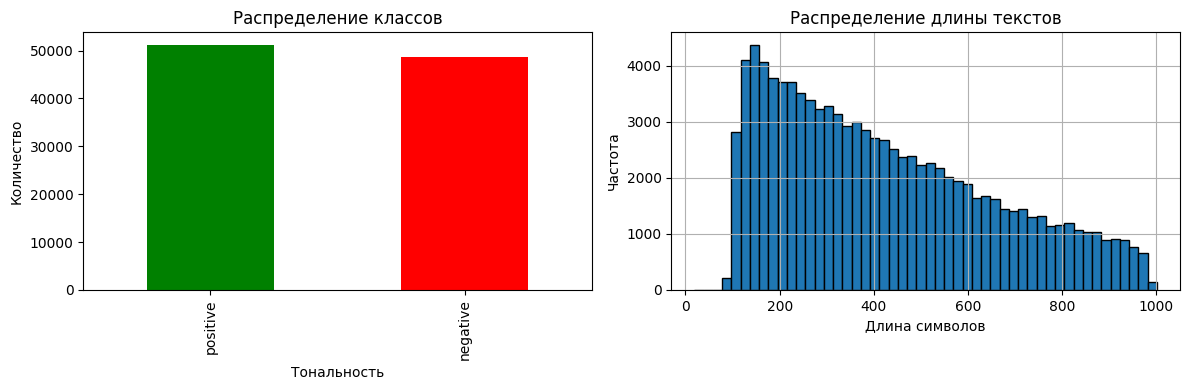


Статистика по длине текстов
count    99978.000000
mean       422.401218
std        231.931679
min         19.000000
25%        226.000000
50%        378.000000
75%        584.000000
max       1001.000000
Name: text_length, dtype: float64

Примеры текстов по классам

--- positive ---
stuning even for the nongamer this sound track was beautiful it paints the senery in your mind so well i would recomend it even to people who hate vid game music i have played the game chrono cross bu

--- negative ---
buyer beware this is a selfpublished book and if you want to know whyread a few paragraphs those star reviews must have been written by ms haddons family and friendsor perhaps by herself i cant imagin


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve().parents[0]

sys.path.append(str(PROJECT_ROOT))
from configs.config import PROCESSED_DIR, MODEL_DIR

# Переходим в корень проекта
os.chdir(Path.cwd().parent)
df = pd.read_csv(PROCESSED_DIR / "amazon_reviews_processed.csv")

print("Размер данных")
print(f"Строк: {len(df)}, Колонок: {len(df.columns)}")
print(f"Память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nПервые 5 строк")
print(df.head())

print("\nТипы данных")
print(df.dtypes)

print("\nПропуски")
print(df.isnull().sum())

print("\nДубликаты")
print(f"Полных дубликатов: {df.duplicated().sum()}")
print(f"Дубликатов по тексту: {df['text'].duplicated().sum()}")

print("\nРаспределение классов")
print(df['sentiment'].value_counts())
print(f"\nПроценты:\n{df['sentiment'].value_counts(normalize=True) * 100}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Распределение классов
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Распределение классов')
axes[0].set_xlabel('Тональность')
axes[0].set_ylabel('Количество')

# Длина текстов
df['text_length'] = df['text'].str.len()
df['text_length'].hist(bins=50, ax=axes[1], edgecolor='black')
axes[1].set_title('Распределение длины текстов')
axes[1].set_xlabel('Длина символов')
axes[1].set_ylabel('Частота')

plt.tight_layout()

# Создаем папку для сохранения
Path("artifacts").mkdir(exist_ok=True)
plt.savefig('artifacts/eda_distribution.png')
plt.show()

print("\nСтатистика по длине текстов")
print(df['text_length'].describe())

print("\nПримеры текстов по классам")
for sentiment in df['sentiment'].unique():
    print(f"\n--- {sentiment} ---")
    print(df[df['sentiment'] == sentiment]['text'].iloc[0][:200])